# High-Dimensional Data

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Describe the curse and blessing of dimensionality and their practical implications
- Compute and interpret summary statistics across a high-dimensional feature matrix using both manual methods and `DataFrame.describe()`
- Construct histogram grids and scatter plot matrices to explore feature distributions and pairwise relationships, including class-colored visualizations
- Rank features by their correlation with a target variable to identify potentially predictive sensors
- Build and interpret correlation heatmaps, and distinguish Pearson from Spearman rank correlation
- Identify zero-variance and highly correlated features as candidates for removal
:::

Working with data that has many features — more than two or three — presents challenges that do not arise in low-dimensional settings. We live in a three-dimensional world and have strong geometric intuition there, but in data science the number of dimensions equals the number of features, and that number can reach into the thousands or more. This chapter introduces the conceptual and practical tools needed to make sense of high-dimensional datasets before applying any model.

Throughout this chapter we use two contrasting datasets. The **Dow dataset** has 40 continuous process variables from a chemical distillation column — a typical scale for industrial sensor data. The **MNIST dataset** encodes each hand-written digit image as a 64-dimensional pixel vector — a simple example of structured high-dimensional data where every feature has an identical type and scale. Comparing strategies across both datasets builds transferable intuition.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('../settings/plot_style.mplstyle')
clrs = np.array([p['color'] for p in plt.rcParams['axes.prop_cycle']])

## High-Dimensional Dataset Examples

### The Dow Dataset

We load and clean the Dow impurity dataset using the same procedure as Module 4. The function `is_real_and_finite` filters out rows that contain non-numeric or infinite values, which can appear in raw industrial time-series data.

In [2]:
df = pd.read_excel('data/impurity_dataset-training.xlsx')

def is_real_and_finite(x):
    return np.isreal(x) and np.isfinite(x)

# Flag rows where every non-Date column is a finite real number
numeric_map = df[df.columns[1:]].apply(lambda col: col.map(is_real_and_finite))
real_rows = numeric_map.all(axis=1).values

all_data = df[df.columns[1:]].values
X_dow = np.array(all_data[real_rows, :-5], dtype='float')   # 40 input features
y_dow = np.array(all_data[real_rows, -3],  dtype='float').reshape(-1, 1)
df_dow_clean = df[real_rows]

print(f'Dow dataset:  {X_dow.shape[0]} samples × {X_dow.shape[1]} features')

Dow dataset:  10297 samples × 40 features


The Dow dataset has roughly 10,000 time-stamped observations and 40 sensor variables. The last five columns of the raw spreadsheet are derived outputs rather than inputs, so they are excluded from `X_dow`.

### The MNIST Dataset

The MNIST dataset is one of the most widely used benchmark datasets in machine learning. The variant built into scikit-learn contains 1,797 images of hand-written digits 0–9, each represented as an 8×8 grid of pixel intensities in the range [0, 16]. Flattening each image produces a 64-dimensional feature vector.

In [3]:
from sklearn.datasets import load_digits

digits = load_digits()
X_mnist = np.array(digits.data)
y_mnist = np.array(digits.target)

print(f'MNIST dataset: {X_mnist.shape[0]} samples × {X_mnist.shape[1]} features')

MNIST dataset: 1797 samples × 64 features


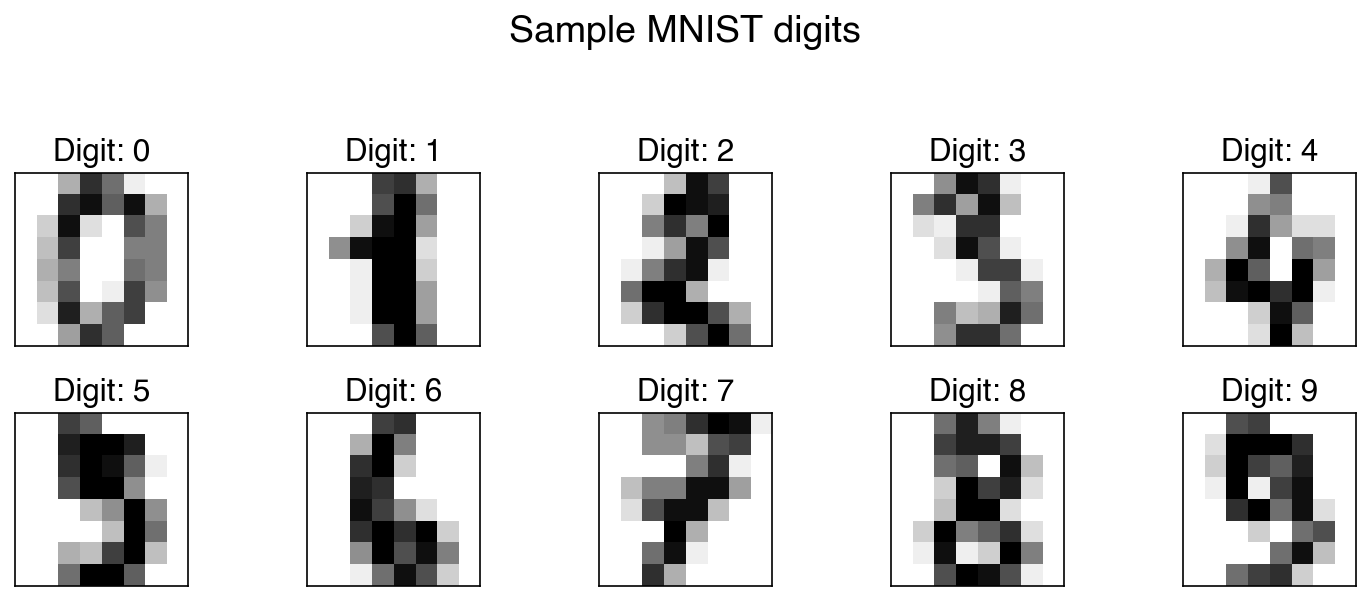

In [4]:
def show_image(data, n, ax=None, title=None):
    """Display the n-th row of data as an 8×8 grayscale image."""
    if ax is None:
        fig, ax = plt.subplots()
    img = data[n].reshape(8, 8)
    ax.imshow(img, cmap='binary', vmin=0, vmax=16)
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    show_image(X_mnist, i, ax=ax, title=f'Digit: {y_mnist[i]}')
plt.suptitle('Sample MNIST digits', y=1.02)
plt.tight_layout()

Each row of `X_mnist` is a 64-element vector. The `show_image` helper reshapes it back to 8×8 for display. Although the data is stored as a flat vector for modeling purposes, the spatial arrangement of pixels carries meaning — structure that informs more advanced models like convolutional neural networks.

:::{exercise}
:label: ex-eda-dataset-shapes

Compute the **samples-to-features ratio** (n/d) for both the Dow and MNIST datasets. If a linear model has roughly one free parameter per feature (plus an intercept), what does a low n/d ratio imply about the risk of overfitting? Which dataset is more at risk?
:::

## The Curse and the Blessing of Dimensionality

Dimensionality in data science is not the same as the three physical dimensions we navigate daily. In data science, dimensionality equals the number of features, and it can reach thousands or more. Two complementary phenomena govern what happens as dimensionality grows.

**The curse of dimensionality** arises because the volume of a high-dimensional space grows exponentially with the number of dimensions. Consider a $d$-dimensional hypercube of side length $L$: its volume is $V_d = L^d$. To sample this space uniformly at resolution $\Delta L = L/N$ requires $N^d$ grid points. For a moderate $N = 10$ and $d = 100$ (common in process data), that is $10^{100}$ points — far more than the number of atoms in the observable universe. In practice this means that any finite dataset becomes exponentially sparse as $d$ grows, making distance-based methods and density estimation unreliable.

**The blessing of dimensionality** is a lesser-known counterpart. Because data becomes sparse in high dimensions, points that might overlap in low dimensions tend to become well-separated as dimensions increase. This can make classification easier: high-dimensional data is often more linearly separable than the same data projected to a lower-dimensional space. Additionally, individual features tend to look more Gaussian in high dimensions due to averaging effects.

The curse always applies; the blessing is not guaranteed. In general, adding uninformative features makes problems harder.

The plots below use two-class data to make the *blessing* concrete: a third feature pulls apart classes that overlap in 2D.

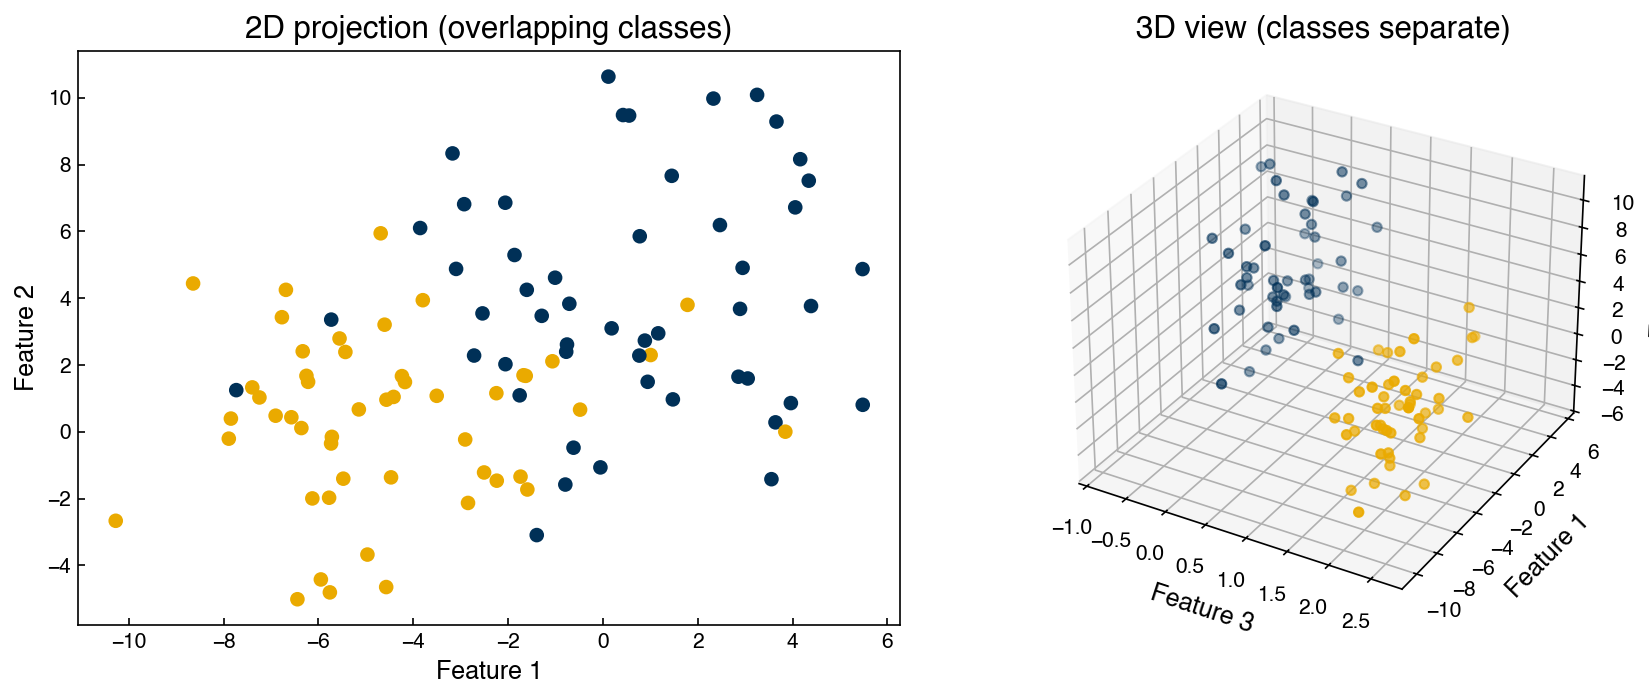

In [5]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs

rng = np.random.default_rng(3)
X2, y2 = make_blobs(100, 2, centers=2, cluster_std=3.0, random_state=3)
z = rng.normal(y2 * 2, 0.3)

X3 = np.column_stack([X2, z])

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                          subplot_kw={})
# 2D view
axes[0].scatter(X3[:, 0], X3[:, 1], c=clrs[y2])
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title('2D projection (overlapping classes)')

# 3D view via a second axes
fig.delaxes(axes[1])
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(X3[:, 2], X3[:, 0], X3[:, 1], c=clrs[y2])
ax3d.set_xlabel('Feature 3')
ax3d.set_ylabel('Feature 1')
ax3d.set_zlabel('Feature 2')
ax3d.set_title('3D view (classes separate)')
plt.tight_layout()

Adding the third feature separates the two classes that overlapped in 2D — a concrete illustration of the blessing. However, if Feature 3 were pure noise, the added dimension would only degrade model performance.

The very same points also reveal the *curse*. No points were added in the 3D view, yet they now have to fill a larger space. We can quantify this with the **sampling density** (points per unit volume of the data's bounding box) and the average distance from each point to its nearest neighbor:

In [6]:
def sampling_density(X):
    """Points per unit volume of the data's bounding box."""
    ranges = X.max(axis=0) - X.min(axis=0)
    return len(X) / np.prod(ranges)

def mean_nn_distance(X):
    """Average distance from each point to its nearest neighbor."""
    D = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=-1)
    np.fill_diagonal(D, np.inf)
    return D.min(axis=1).mean()

for label, X in [('2D', X3[:, :2]), ('3D', X3)]:
    print(f'{label}: sampling density = {sampling_density(X):8.4f} points/unit-volume, '
          f'mean nearest-neighbor distance = {mean_nn_distance(X):.2f}')

2D: sampling density =   0.4056 points/unit-volume, mean nearest-neighbor distance = 0.72
3D: sampling density =   0.1172 points/unit-volume, mean nearest-neighbor distance = 0.94


The density drops sharply and the typical nearest-neighbor distance grows, even though no data was added — exactly the sparsity that makes distance- and density-based methods unreliable in high dimensions. Both effects trace back to the same fact, that volume grows with dimension; which one wins depends on whether the extra dimensions carry signal or noise.

:::{exercise}
:label: ex-eda-volume-growth

Write a function `grid_points(d, N)` that returns the number of uniform grid points needed to cover a $d$-dimensional unit hypercube at resolution $1/N$ (i.e. $N^d$). Plot $\log_{10}(\text{grid points})$ vs $d$ for $N = 10$ and $d \in \{1, 2, \ldots, 20\}$. Add a horizontal reference line at $\log_{10}(10^{83})$ (approximate number of atoms in the observable universe). At what dimension does the required sampling exceed this limit?
:::

## Inspecting High-Dimensional Features

Unlike a 1D or 2D dataset, we cannot simply scatter-plot a high-dimensional feature matrix. However, targeted visualizations of individual features and pairs of features remain essential for catching data quality issues, understanding scale and distribution, and identifying informative structure before modeling.

### Summary Statistics

The most direct starting point is computing per-feature summary statistics: mean, standard deviation, minimum, and maximum. For image data like MNIST, these statistics can be visualized directly as images.

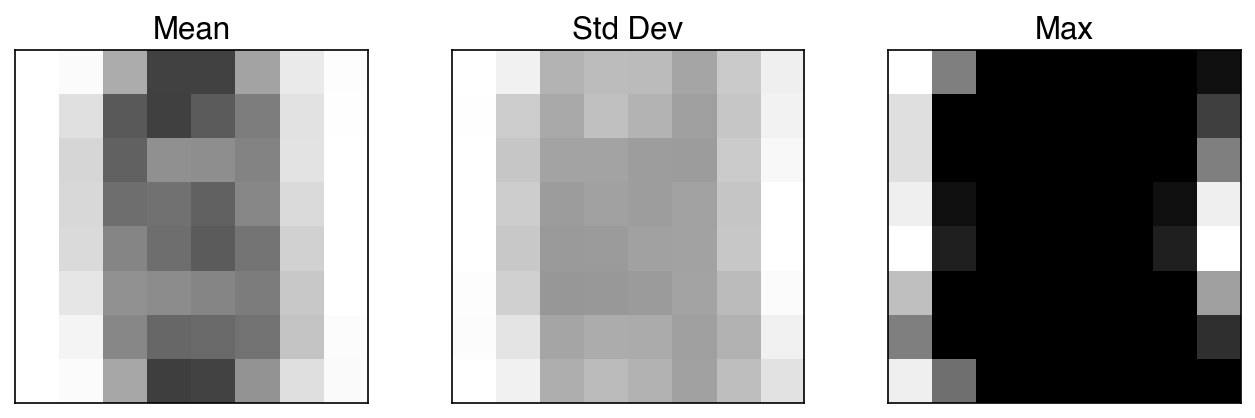

In [7]:
means  = X_mnist.mean(axis=0).reshape(1, -1)
stdevs = X_mnist.std(axis=0).reshape(1, -1)
maxima = X_mnist.max(axis=0).reshape(1, -1)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, stat, title in zip(axes,
                            [means, stdevs, maxima],
                            ['Mean', 'Std Dev', 'Max']):
    show_image(stat, 0, ax=ax, title=title)
plt.tight_layout()

The mean image shows that pixel intensities are highest near the center of the 8×8 grid — all digits are roughly centered. The standard deviation image highlights pixels that vary a lot across digits; these are the most *informative* pixels. The maximum image reveals that several corner pixels are essentially always zero: their maximum value is near zero, meaning they carry no information regardless of which digit is shown. These zero-variance features are candidates for removal before modeling.

**Demonstration: Summary statistics for the Dow dataset**

For tabular data with named features, a DataFrame is more readable than an image:

In [8]:
feature_names = df.columns[1:-5]
summary = pd.DataFrame({
    'mean': X_dow.mean(axis=0),
    'std':  X_dow.std(axis=0),
    'min':  X_dow.min(axis=0),
    'max':  X_dow.max(axis=0),
}, index=feature_names)
summary.round(3)

,mean,std,min,max
x1:Primary Column Reflux Flow,363.769,75.648,-1.356,435.227
x2:Primary Column Tails Flow,48.043,8.344,-0.137,56.118
x3:Input to Primary Column Bed 3 Flow,2531.651,571.295,-0.363,3222.690
x4:Input to Primary Column Bed 2 Flow,2462.788,503.647,-1.119,3130.710
x5:Primary Column Feed Flow from Feed Column,111.402,27.230,-0.977,138.763
x6:Primary Column Make Flow,105.253,28.085,-0.033,128.979
x7:Primary Column Base Level,54.302,9.015,-0.127,136.216
x8:Primary Column Reflux Drum Pressure,39.617,4.618,2.185,80.739
x9:Primary Column Condenser Reflux Drum Level,52.162,8.890,-1.235,103.105
x10:Primary Column Bed1 DP,10.620,3.791,0.126,64.262


`pandas` provides the same information in one call with `DataFrame.describe()`:

In [9]:
pd.DataFrame(X_dow, columns=feature_names).describe().round(3)

,x1:Primary Column Reflux Flow,x2:Primary Column Tails Flow,x3:Input to Primary Column Bed 3 Flow,x4:Input to Primary Column Bed 2 Flow,x5:Primary Column Feed Flow from Feed Column,x6:Primary Column Make Flow,x7:Primary Column Base Level,x8:Primary Column Reflux Drum Pressure,x9:Primary Column Condenser Reflux Drum Level,x10:Primary Column Bed1 DP,...,x31: Secondary Column Bed 2 Temperature,x32: Secondary Column Tray 2 Temperature,x33: Secondary Column Tray 1 Temperature,x34: Secondary Column Tails Temperature,x35: Secondary Column Tails Concentration,x36: Feed Column Recycle Flow,x37: Feed Column Tails Flow to Primary Column,x38: Feed Column Calculated DP,x39: Feed Column Steam Flow,x40: Feed Column Tails Flow
count,10297.000,10297.000,10297.000,10297.000,10297.000,10297.000,10297.000,10297.000,10297.000,10297.000,...,10297.000,10297.000,10297.000,10297.000,10297.000,10297.000,10297.000,10297.000,10297.000,10297.000
mean,363.769,48.043,2531.651,2462.788,111.402,105.253,54.302,39.617,52.162,10.620,...,55.753,82.839,103.999,138.421,0.015,62.291,45.008,66.467,8.318,113.176
std,75.652,8.344,571.323,503.672,27.231,28.087,9.015,4.618,8.890,3.791,...,6.701,18.304,18.990,18.885,0.026,3.291,0.001,15.050,1.789,27.192
min,-1.356,-0.137,-0.363,-1.119,-0.977,-0.033,-0.127,2.185,-1.235,0.126,...,15.182,16.600,15.946,13.957,0.000,45.002,44.998,-2.900,0.000,-0.978
25%,339.678,48.943,2347.260,2341.190,105.135,96.266,54.672,37.811,52.749,7.857,...,55.266,73.444,94.417,140.417,0.013,62.879,45.007,67.292,8.694,106.995
50%,386.493,49.818,2414.810,2603.800,121.046,115.361,55.488,40.993,53.569,11.948,...,56.665,78.181,104.531,142.002,0.014,62.898,45.008,68.898,8.700,122.496
75%,408.479,50.041,2902.500,2661.420,127.254,122.137,56.299,41.012,54.374,13.399,...,57.326,88.314,117.689,142.352,0.015,62.935,45.008,70.610,8.705,128.658
max,435.227,56.118,3222.690,3130.710,138.763,128.979,136.216,80.739,103.105,64.262,...,143.685,145.666,145.132,146.126,1.000,63.580,45.010,150.000,9.023,183.574


Summary statistics can quickly reveal:
- Features with near-zero standard deviation (effectively constant — no predictive value)
- Features on very different scales (e.g. flows in the hundreds vs. concentrations near zero), which may require standardization before distance-based modeling
- Skewed ranges suggesting outliers or bounded physical quantities

:::{exercise}
:label: ex-eda-zero-pixels

Identify all MNIST pixels (features) with standard deviation less than 0.5. Visualize their positions as an 8×8 binary mask using `plt.imshow` (1 = near-zero variance, 0 = informative). How many such pixels are there, and where are they located in the image grid?
:::

### Histogram Plots

Summary statistics reduce each feature to a few numbers and can miss non-Gaussian structure — multimodality, heavy tails, or hard boundaries. Plotting a histogram for every feature gives a richer view of each marginal distribution.

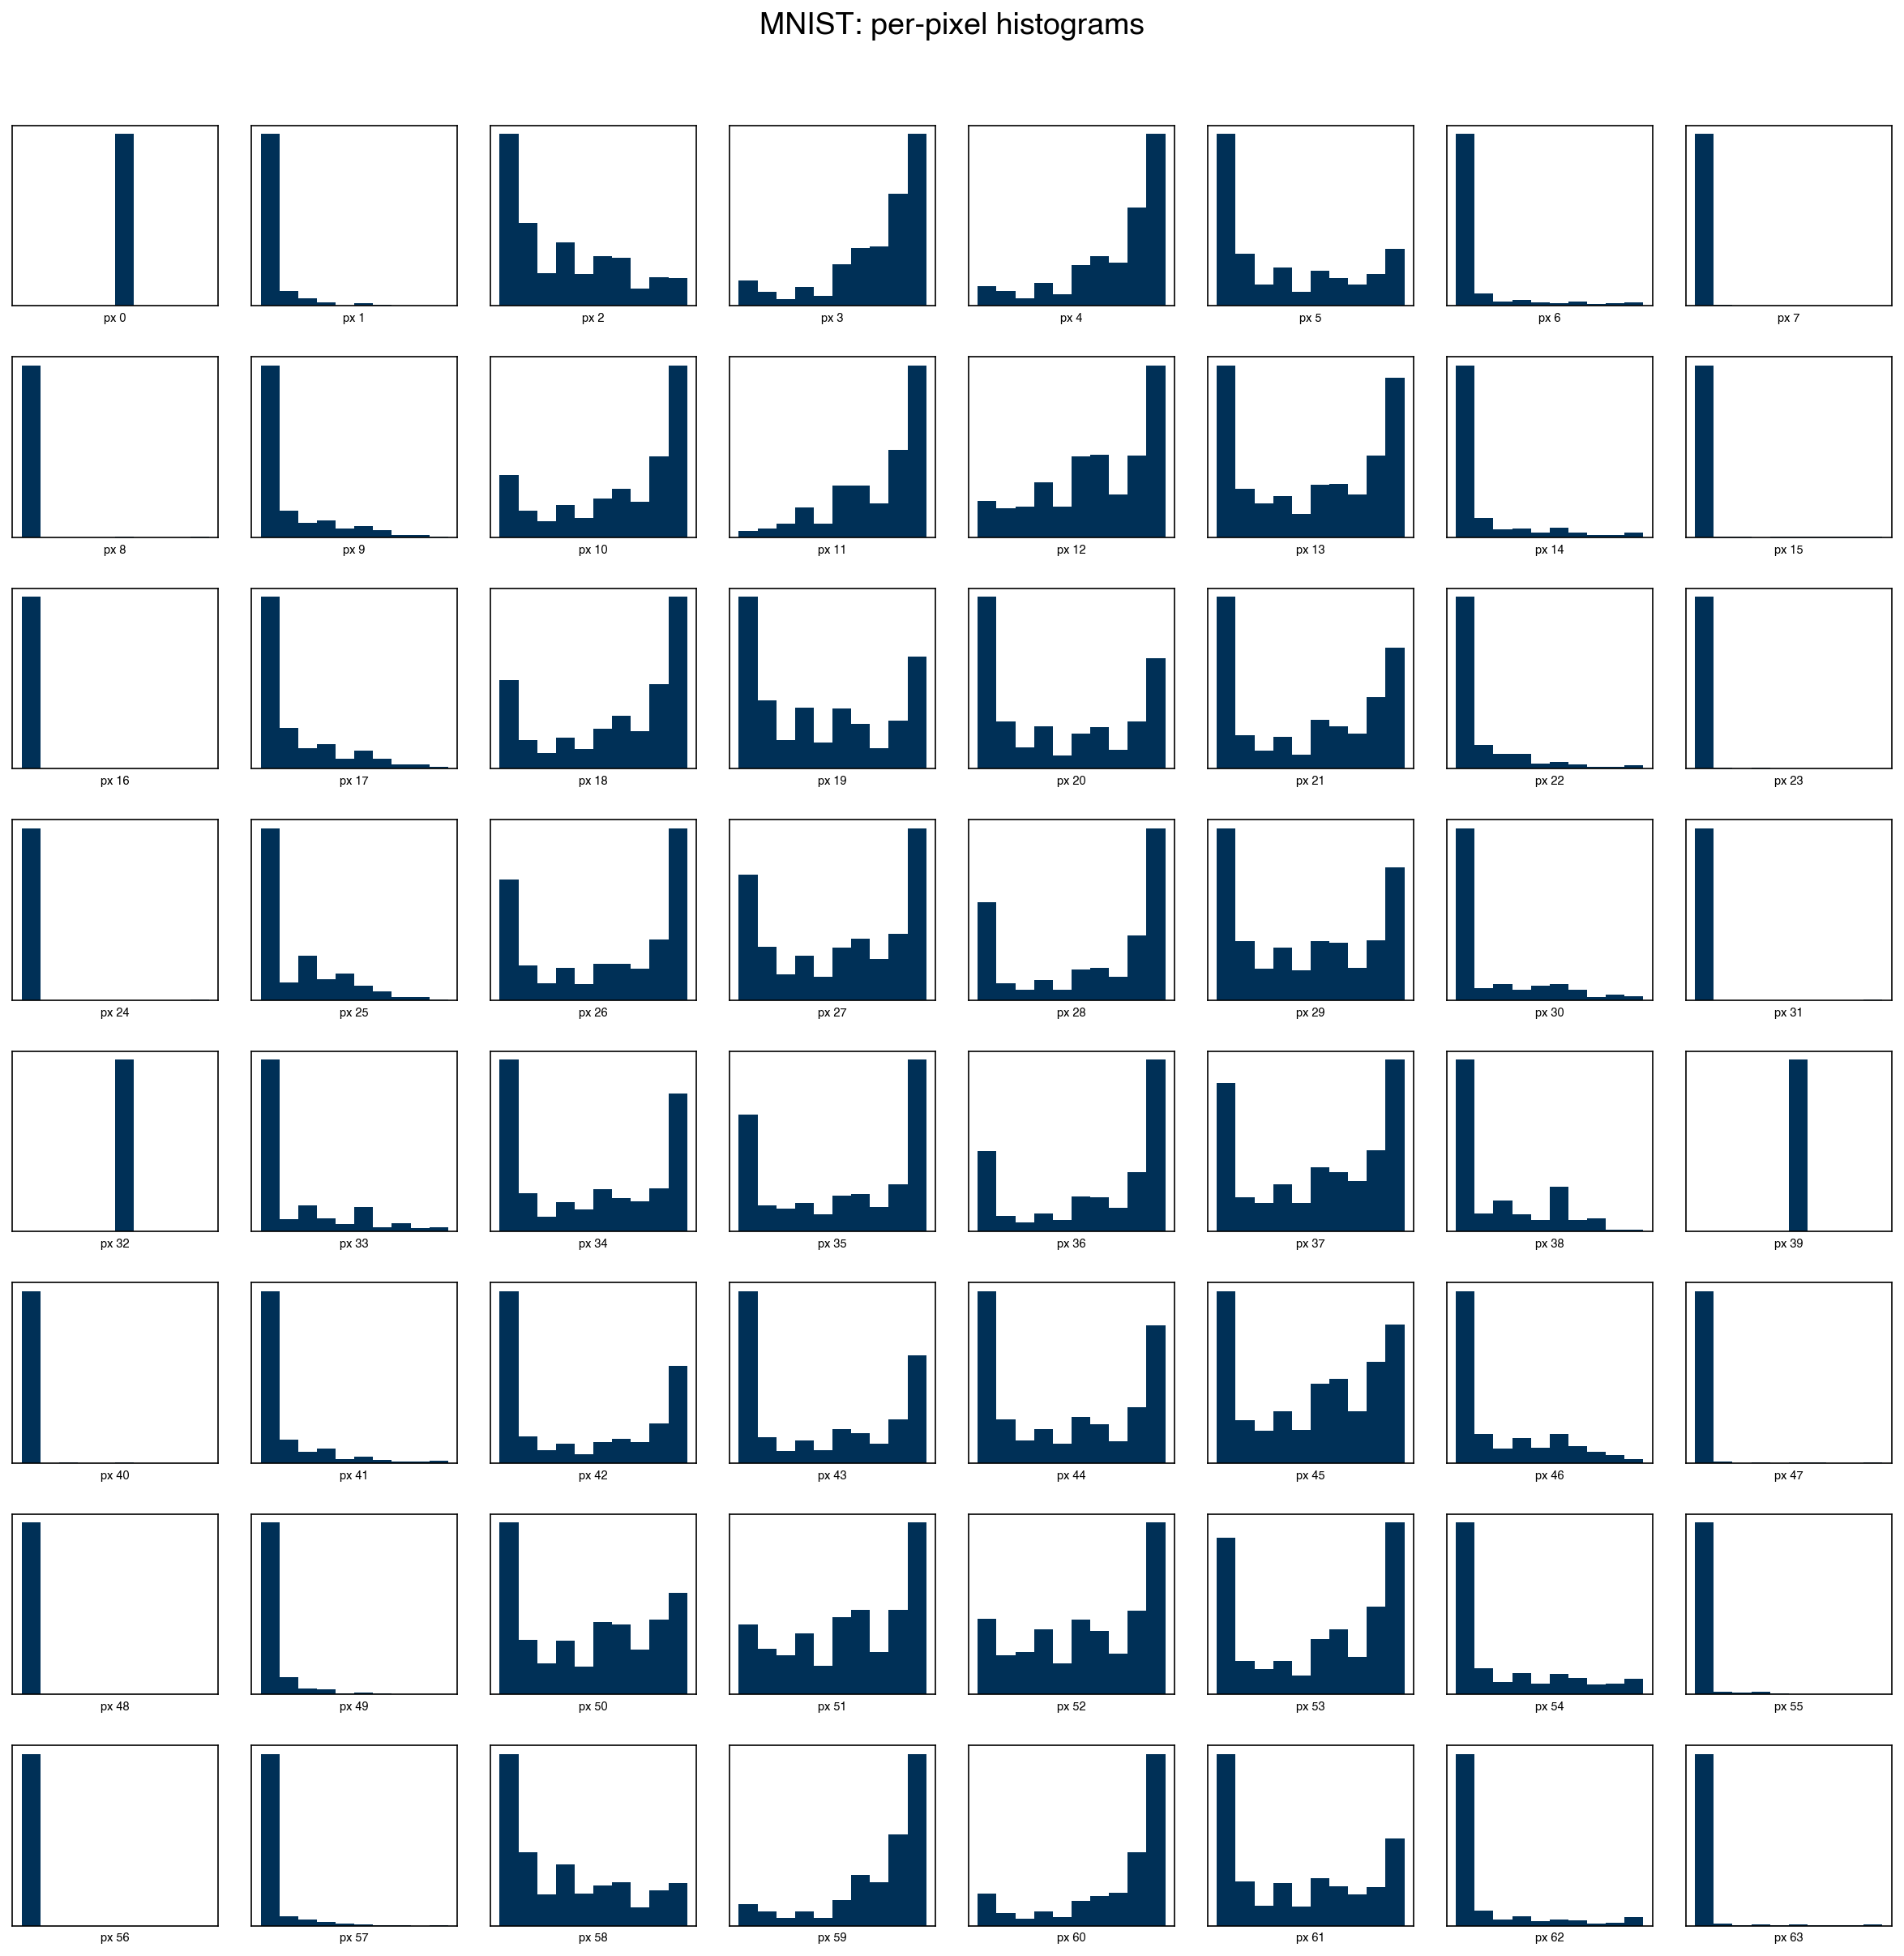

In [10]:
n_side = 8   # 8×8 = 64 features
fig, axes = plt.subplots(n_side, n_side, figsize=(16, 16))
for i, ax in enumerate(axes.ravel()):
    ax.hist(X_mnist[:, i], bins=10, color=clrs[0])
    ax.set_xlabel(f'px {i}', fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle('MNIST: per-pixel histograms', y=1.01)
plt.tight_layout()

:::{note}
**Do these features follow a normal distribution?** No. Most MNIST pixel histograms are strongly non-Gaussian: many corner pixels are almost always zero (spike at 0), while central pixels show bimodal or multimodal distributions reflecting the different shapes of the ten digit classes. This matters for methods that assume normality (e.g. linear discriminant analysis, Gaussian naive Bayes), but is not a problem for tree-based models or SVMs.
:::

## Scatter Plots

Histograms reveal single-feature distributions but say nothing about how features relate to each other. Scatter plots of pairs of features expose correlations, clusters, and outliers that univariate summaries miss.

For a dataset with $d$ features, a full scatter plot matrix has $d^2$ panels — 4,096 panels for MNIST. In practice, we restrict to a small subset of features at a time:

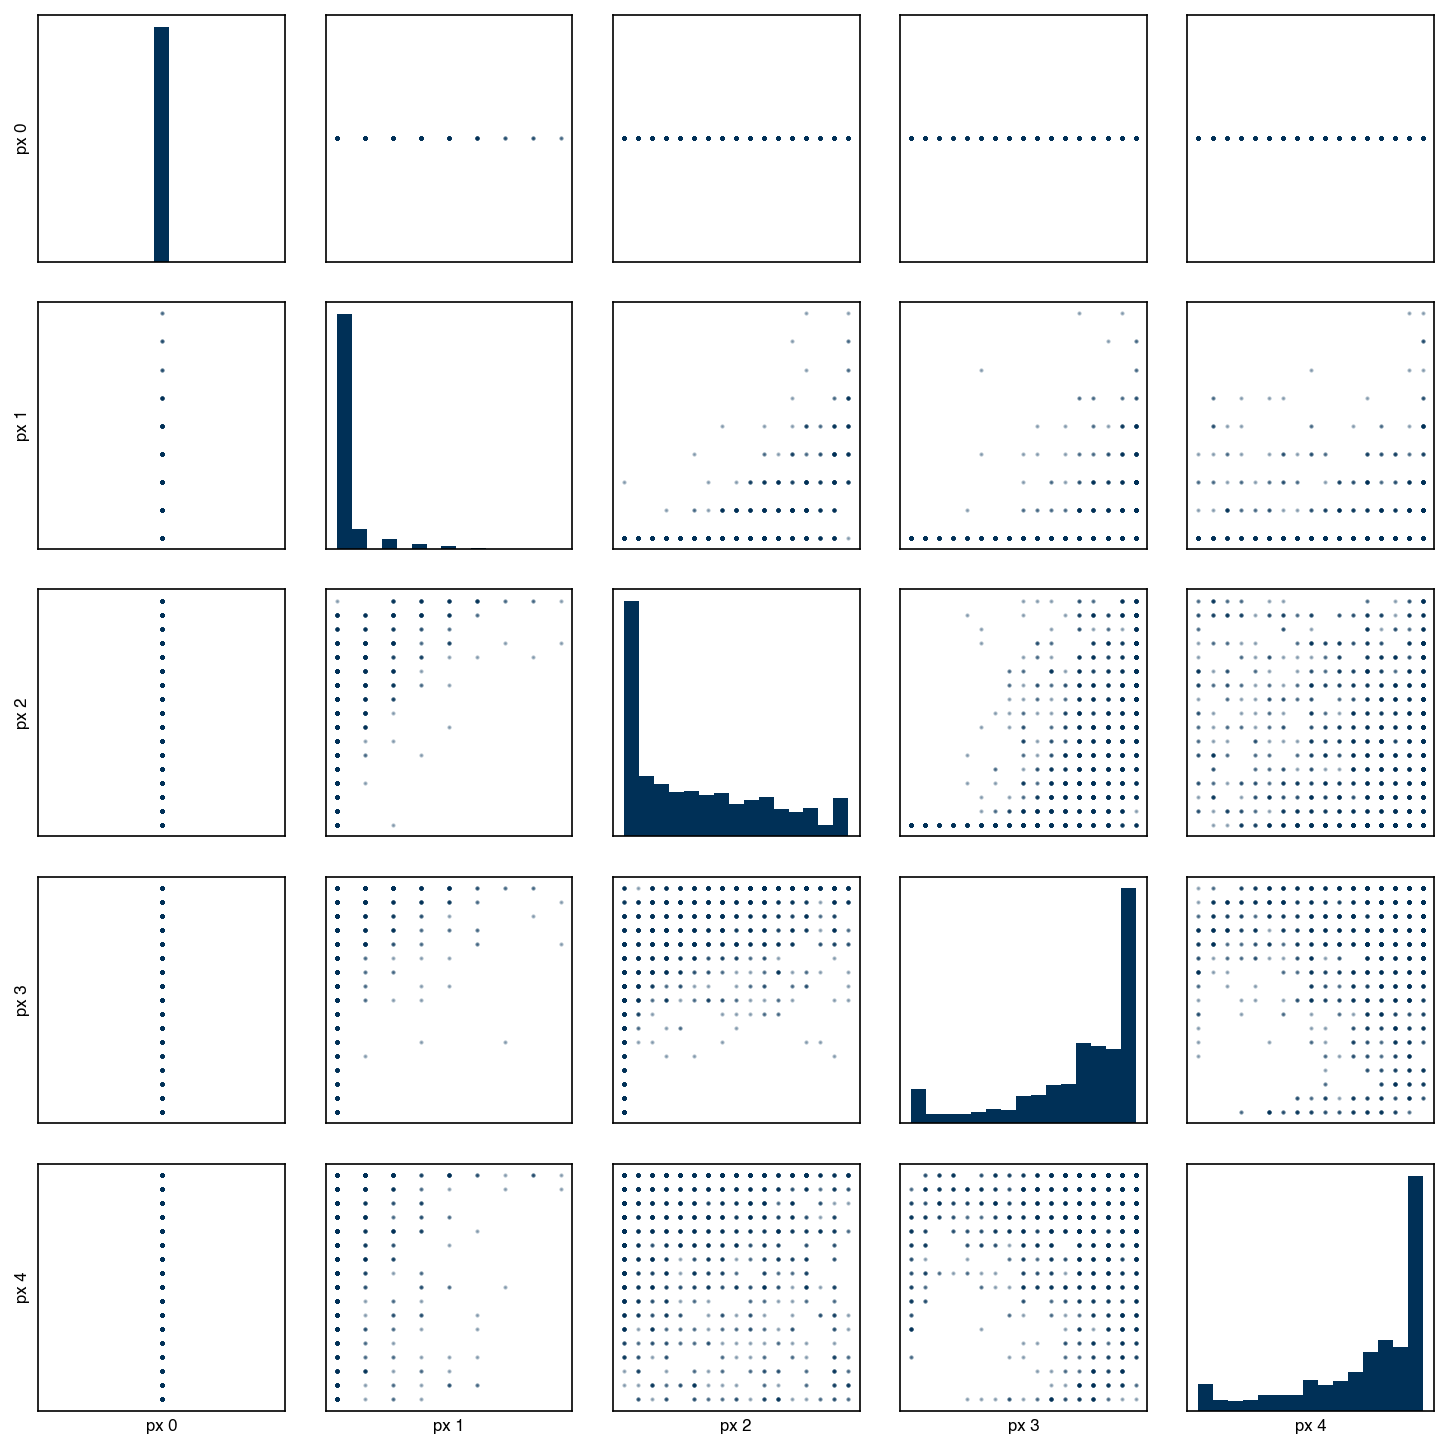

In [11]:
features = [0, 1, 2, 3, 4]   # first 5 MNIST pixels

# Manual matrix: diagonal = histogram, off-diagonal = scatter
n = len(features)
fig, axes = plt.subplots(n, n, figsize=(10, 10))
for i, fi in enumerate(features):
    for j, fj in enumerate(features):
        ax = axes[i, j]
        if i == j:
            ax.hist(X_mnist[:, fi], bins=15, color=clrs[0])
        else:
            ax.scatter(X_mnist[:, fj], X_mnist[:, fi],
                       s=1, alpha=0.3, color=clrs[0])
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(f'px {fi}', fontsize=8)
        if i == n - 1:
            ax.set_xlabel(f'px {fj}', fontsize=8)
plt.tight_layout()

The `seaborn` library provides `pairplot` as a convenient one-liner that produces the same layout with sensible defaults:

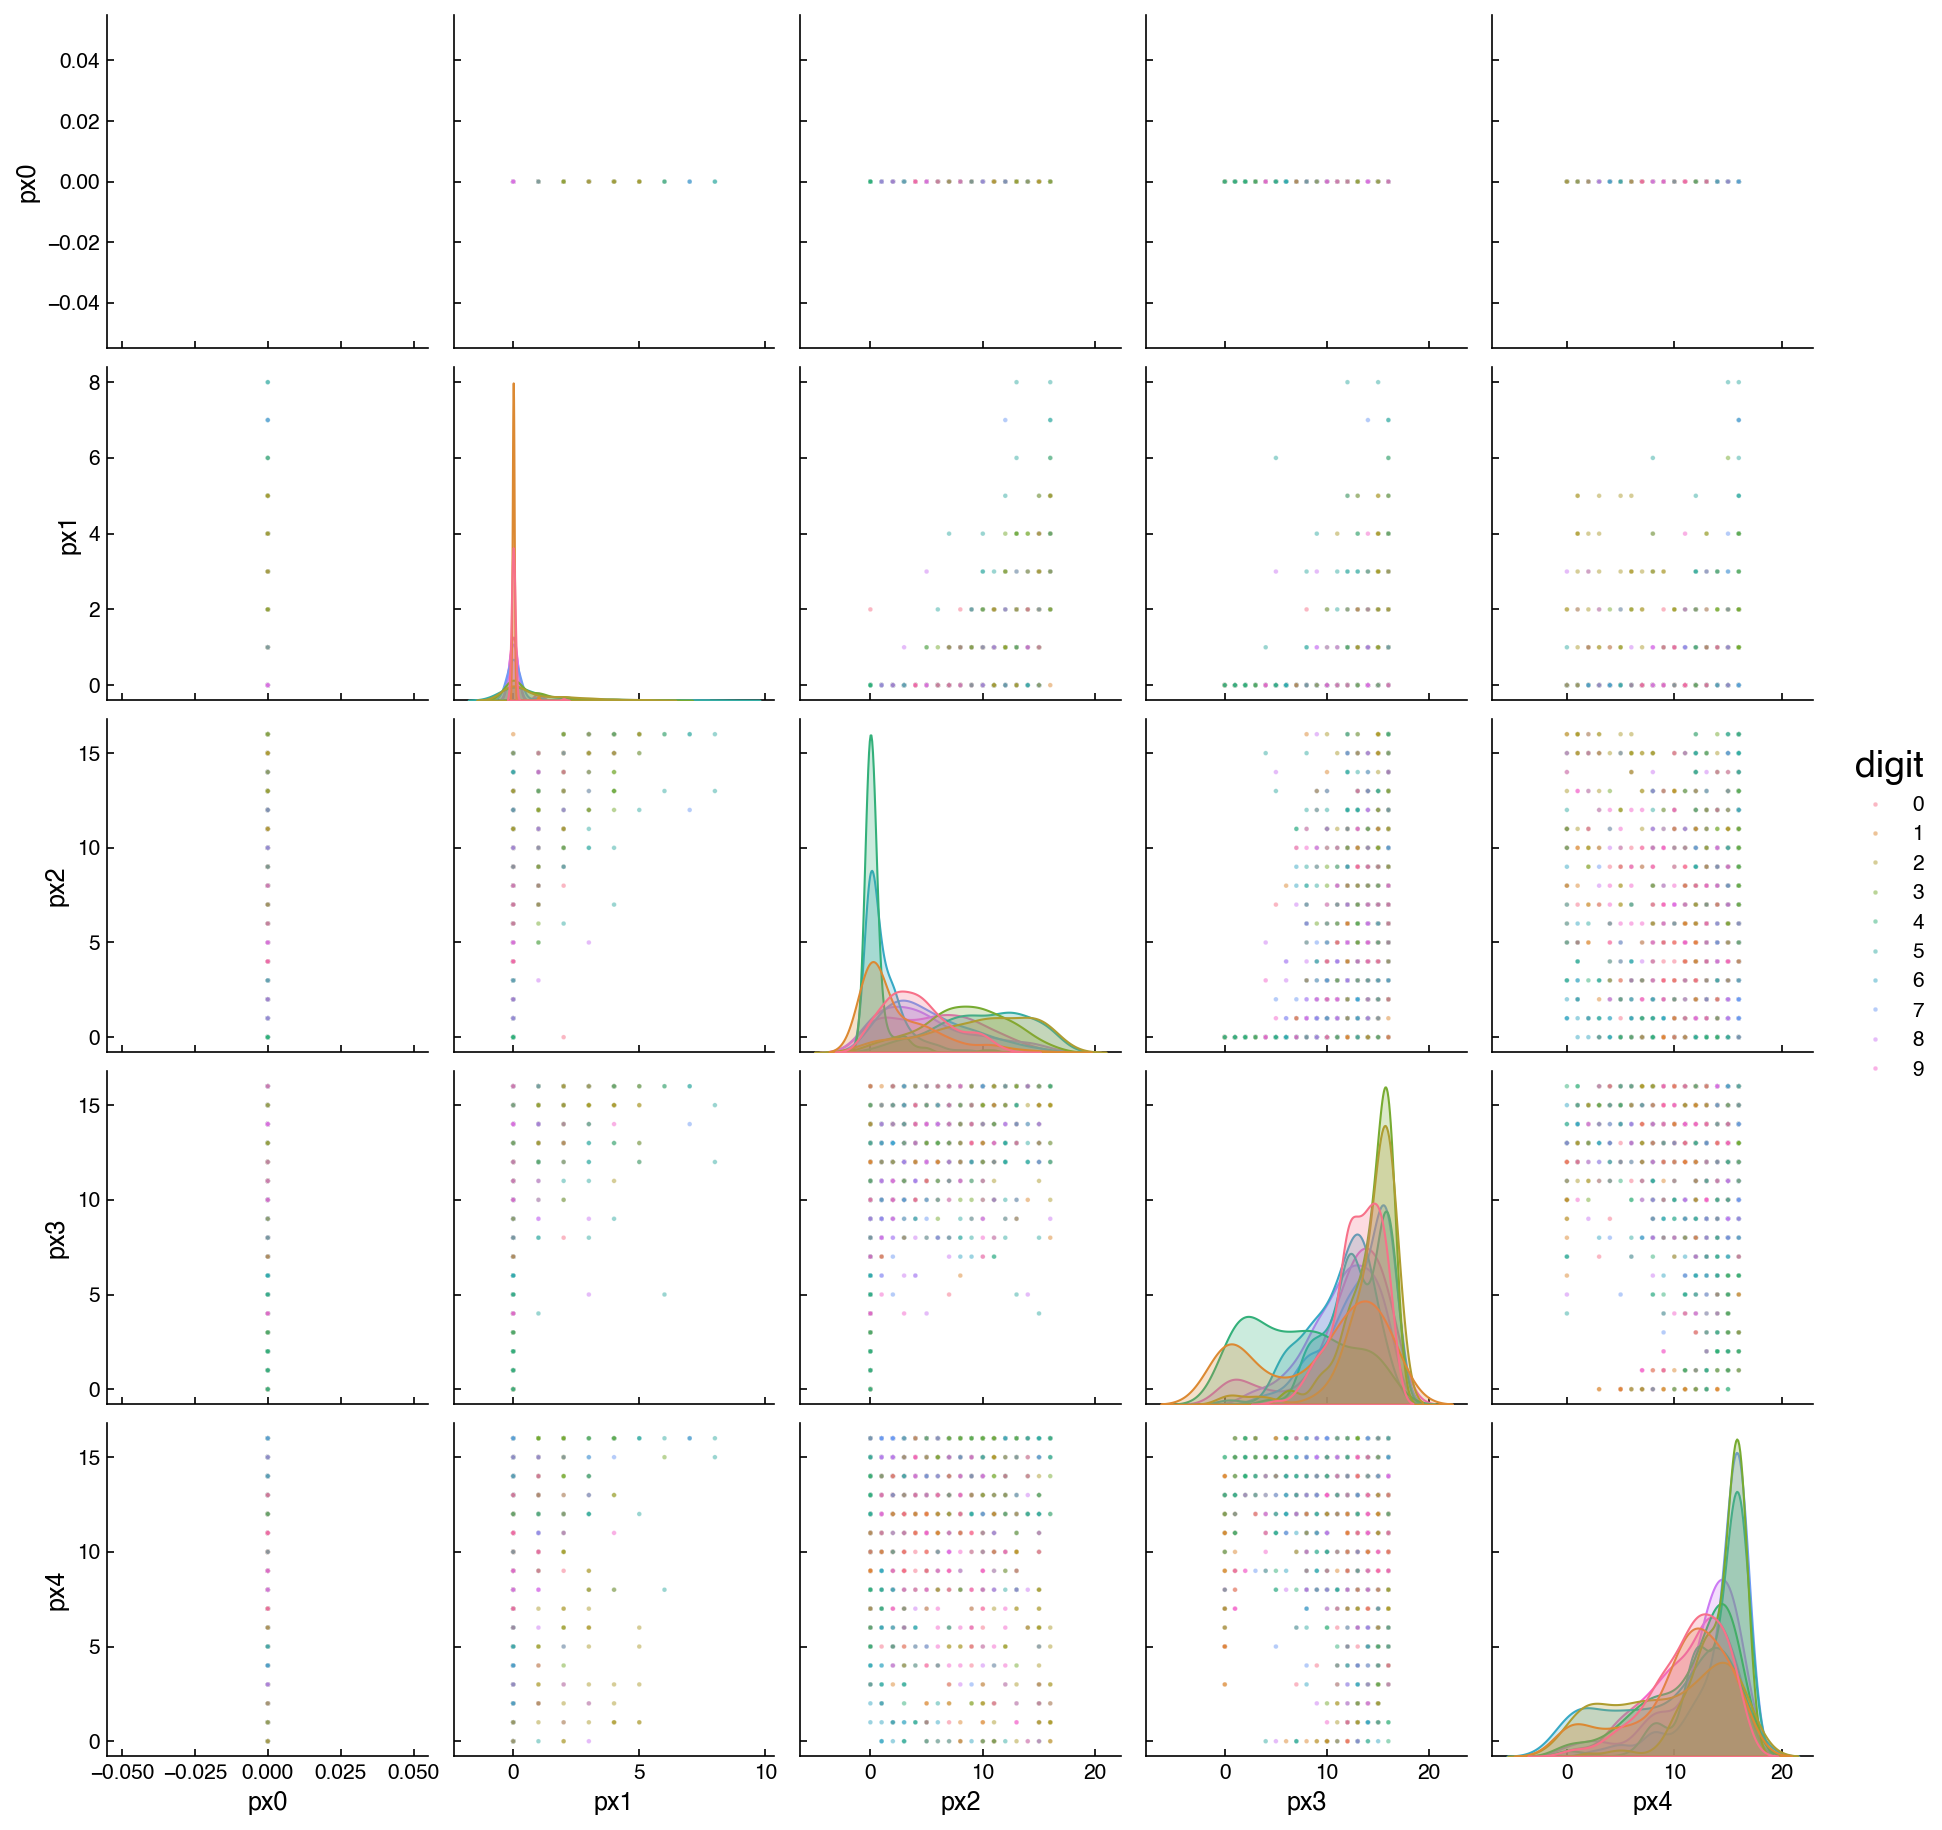

In [12]:
mnist_df = pd.DataFrame(X_mnist, columns=[f'px{i}' for i in range(X_mnist.shape[1])])
mnist_df_plot = mnist_df[[f'px{i}' for i in features]].copy()
mnist_df_plot['digit'] = y_mnist.astype(str)
sns.pairplot(mnist_df_plot, hue='digit', plot_kws={'s': 5, 'alpha': 0.5});

Adding `hue='digit'` reveals class structure that is invisible in a monochrome plot: pixels 0 and 1 (top-left corners) show nearly all digits stacked at zero, while central pixels display separated color clusters corresponding to different digit classes. Panels where the colored clusters overlap heavily indicate features that will be difficult to use for classification on their own.

:::{note}
**What does a vertical or horizontal line in a scatter plot mean?** It means one of the two features plotted on that panel takes only a single value (or a very narrow range of values) across the dataset. The feature contributes no information to differentiate observations. This is exactly the near-zero-variance pattern identified in the histogram and summary statistics sections, and is a strong signal to exclude that feature before modeling.
:::

For the Dow dataset with continuous process variables, the pairplot shows smoother scatter patterns:

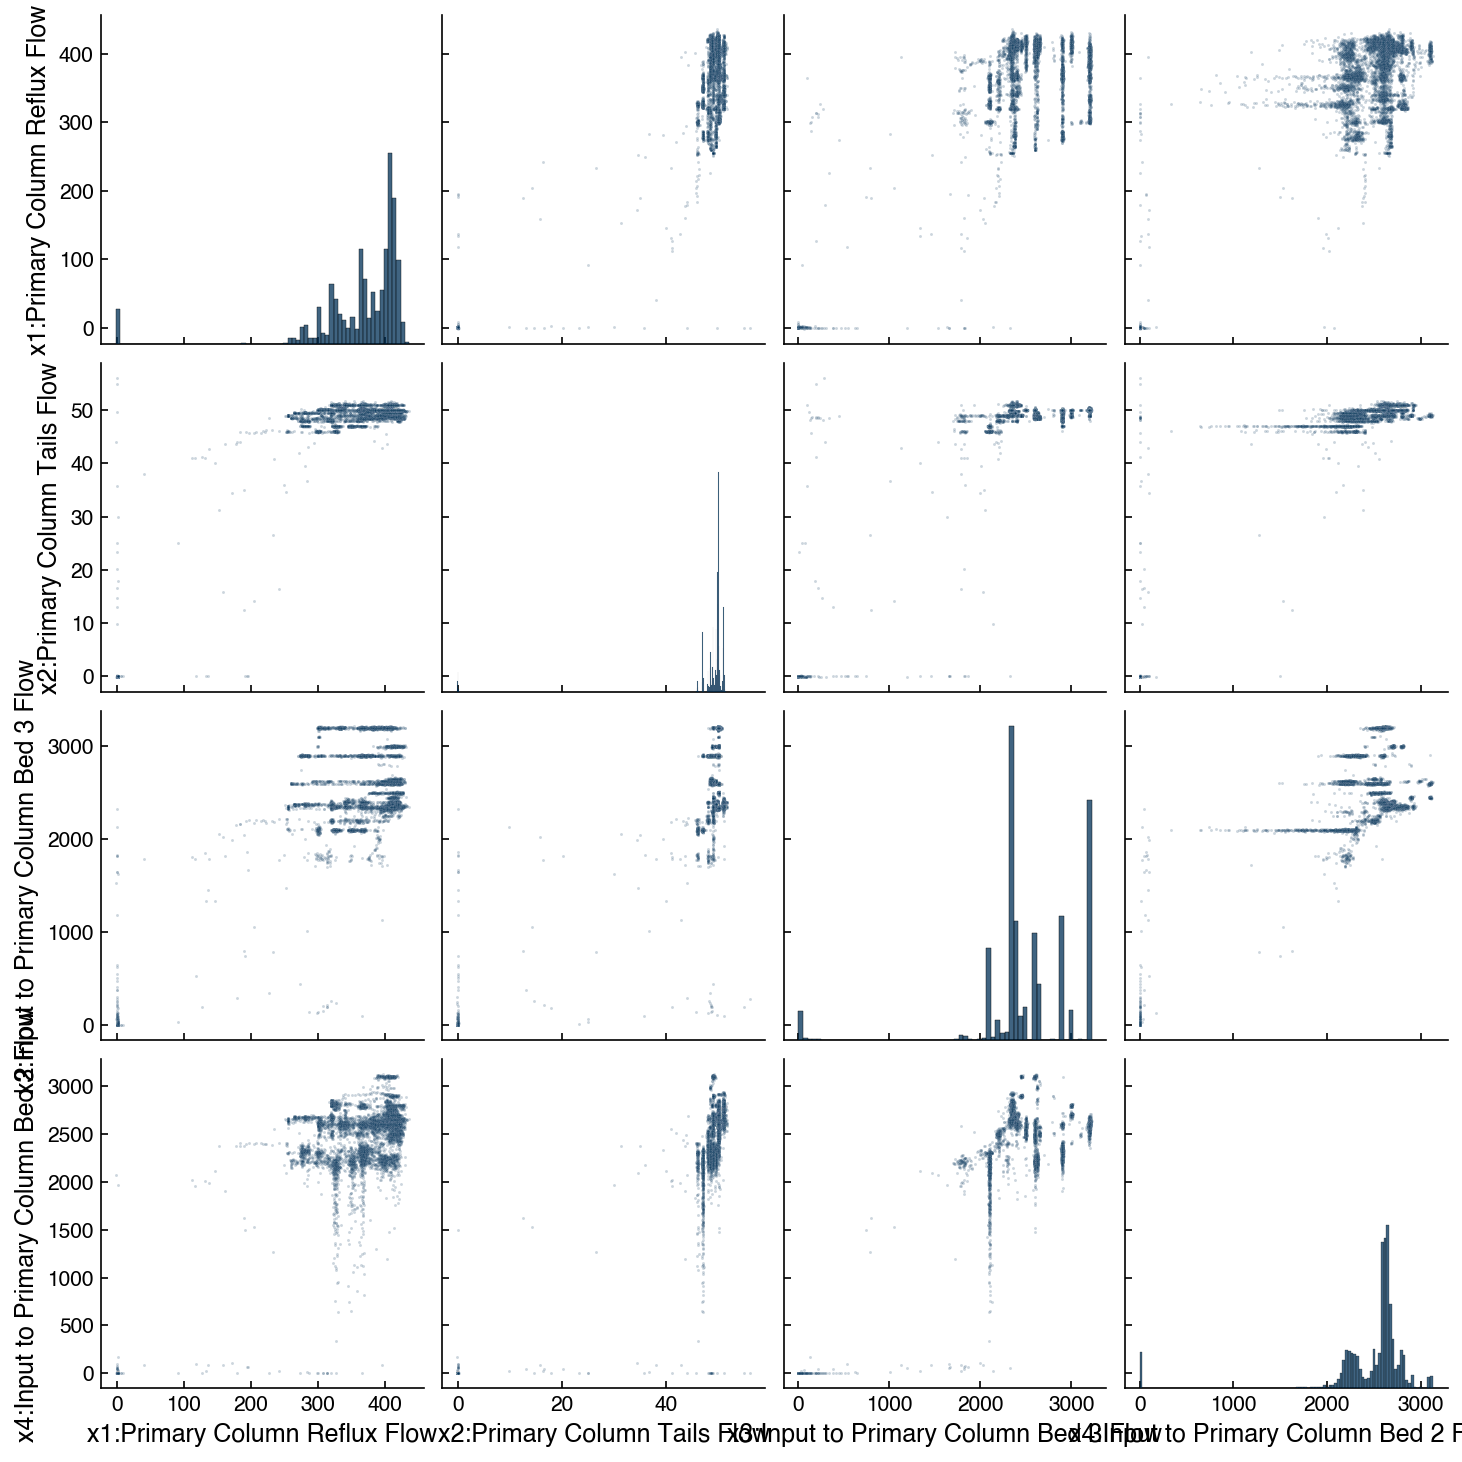

In [13]:
include_cols = list(df_dow_clean.columns[1:5])
sns.pairplot(df_dow_clean[include_cols].apply(pd.to_numeric, errors='coerce').dropna(),
             plot_kws={'s': 2, 'alpha': 0.2});

### Joint Plots

A joint plot zooms in on a single pair of features, showing the scatter and marginal distributions together. This is useful when a pairplot has identified a relationship worth examining in detail:

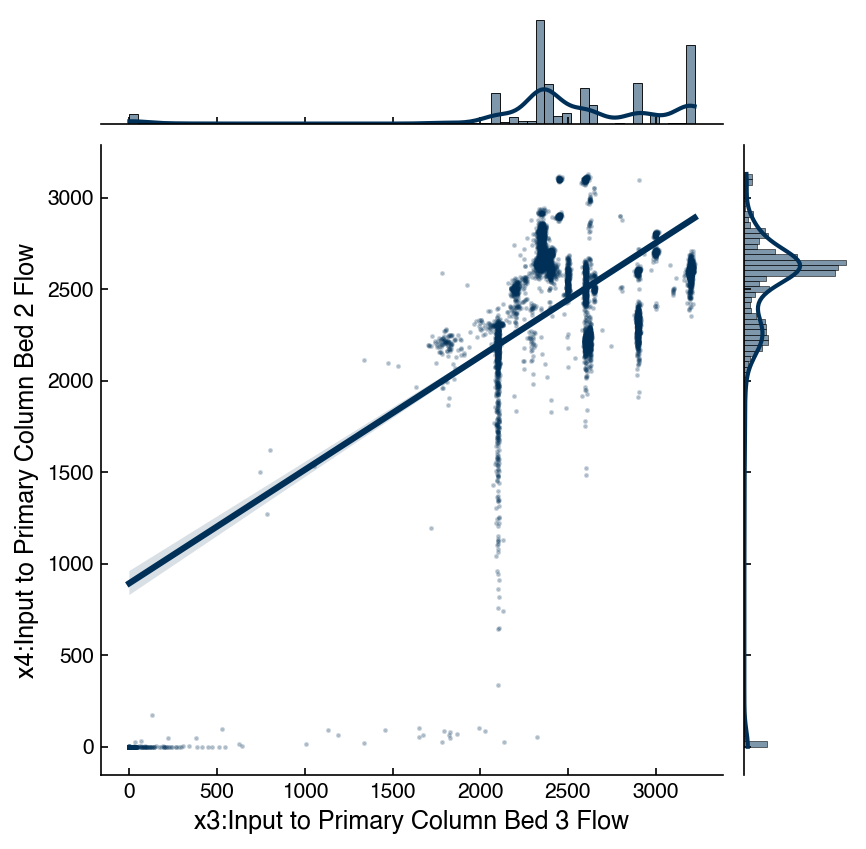

In [14]:
x_col = df_dow_clean.columns[3]   # x3: Input to Primary Column Bed 3 Flow
y_col = df_dow_clean.columns[4]   # x4: Input to Primary Column Bed 2 Flow

sns.jointplot(
    x=x_col, y=y_col,
    data=df_dow_clean.apply(pd.to_numeric, errors='coerce').dropna(),
    kind='reg',
    scatter_kws={'s': 2, 'alpha': 0.2},
);

The `kind='reg'` option overlays a linear regression fit with a confidence band, and prints the Pearson correlation coefficient and p-value. For x3 and x4 (two feed flows to the same column), a strong positive correlation is expected physically — both flows tend to increase or decrease together with production rate.

### Correlation Matrix

While a scatter plot matrix gives rich pairwise information, it is impractical for datasets with more than ~10 features. The correlation matrix compresses pairwise relationships into a single number per pair: the Pearson correlation coefficient. Values near ±1 indicate strong linear relationships; values near 0 indicate weak or no linear relationship.

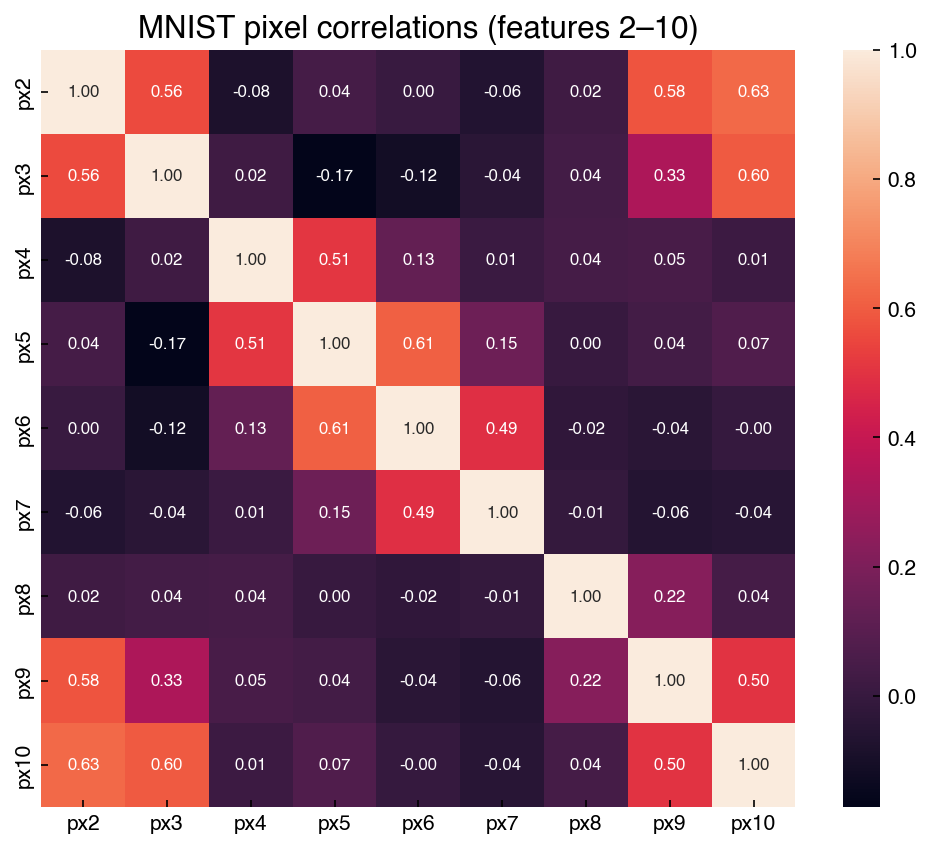

In [15]:
# MNIST correlation matrix — select features 2–10 (avoid near-zero-variance corner pixels)
features_corr = list(range(2, 11))
corr_mnist = mnist_df[[f'px{i}' for i in features_corr]].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_mnist, annot=True, fmt='.2f',
            annot_kws={'fontsize': 8}, ax=ax)
ax.set_title('MNIST pixel correlations (features 2–10)')
plt.tight_layout()

For the Dow dataset, feature labels make the heatmap directly interpretable:

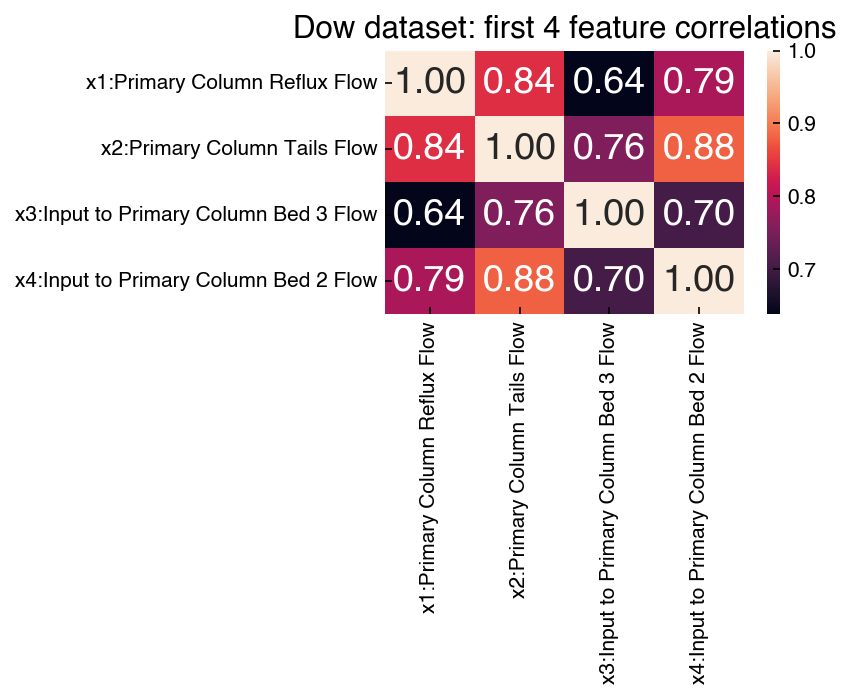

In [16]:
corr_dow = df_dow_clean[include_cols].apply(pd.to_numeric, errors='coerce').dropna().corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_dow, annot=True, fmt='.2f', ax=ax)
ax.set_title('Dow dataset: first 4 feature correlations')
plt.tight_layout()

**Demonstration: Feature–target correlations for the Dow dataset**

A correlation heatmap between features is useful for detecting redundancy, but for supervised learning the most actionable analysis is how strongly each feature correlates with the *target variable* — here, the product impurity. Ranking features by $|r|$ with the target gives a quick first screen for which sensors are predictive.

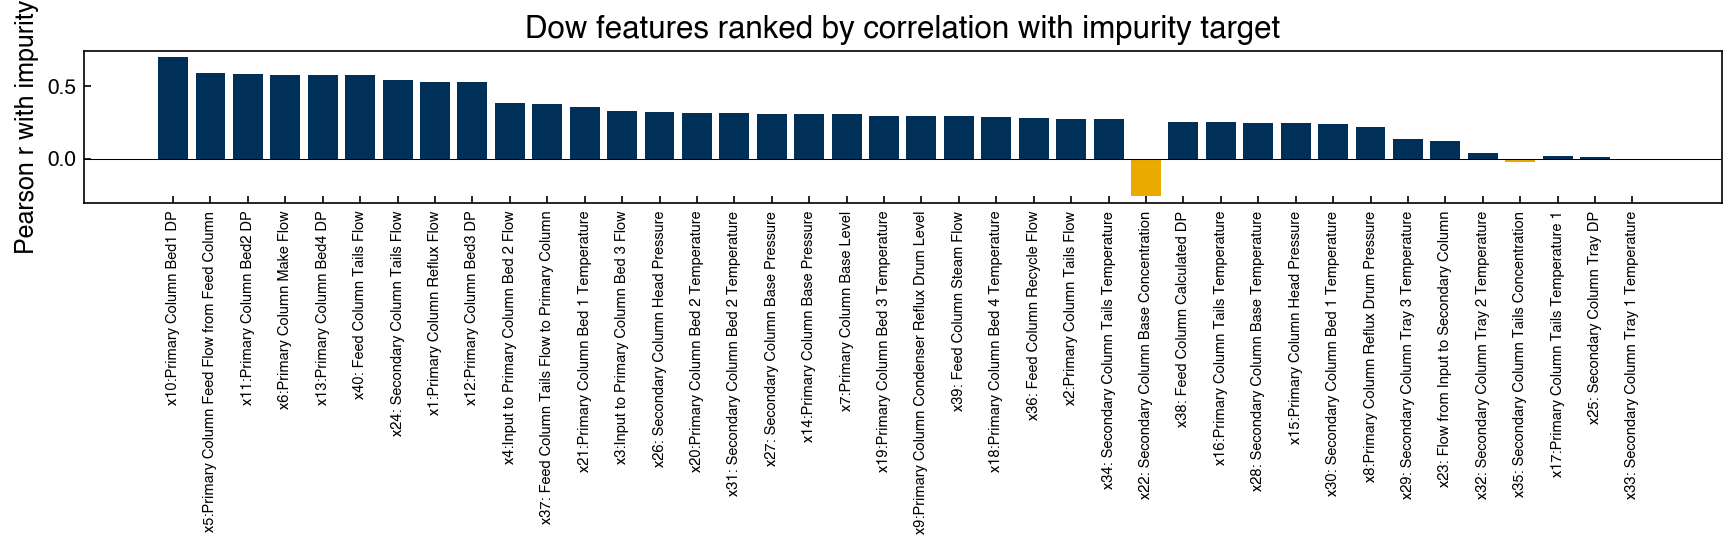

In [17]:
corr_target = np.array([
    np.corrcoef(X_dow[:, i], y_dow.ravel())[0, 1]
    for i in range(X_dow.shape[1])
])
order = np.argsort(np.abs(corr_target))[::-1]

fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = [clrs[0] if c >= 0 else clrs[1] for c in corr_target[order]]
ax.bar(range(X_dow.shape[1]), corr_target[order], color=bar_colors)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xticks(range(X_dow.shape[1]))
ax.set_xticklabels(feature_names[order], rotation=90, fontsize=7)
ax.set_ylabel('Pearson r with impurity')
ax.set_title('Dow features ranked by correlation with impurity target')
plt.tight_layout()

Most features show weak linear correlation with the impurity target ($|r| < 0.3$), which is typical of industrial process data where the output depends on complex, nonlinear interactions. A handful of features — particularly those related to reboiler and condenser flows — show stronger correlations and are likely to appear as important predictors in regression models.

**Demonstration: Correlation as a regression slope**

There is a precise algebraic relationship between the Pearson correlation coefficient and regression: if two features $x_i$ and $x_j$ are each standardized to zero mean and unit variance, the slope of a simple ordinary least squares regression of $x_j$ on $x_i$ equals their Pearson correlation coefficient. This connection helps interpret correlation matrices in terms of predictive relationships.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Standardize x3 and x4 from the Dow dataset
X_pair = df_dow_clean[include_cols[:2]].apply(pd.to_numeric, errors='coerce').dropna().values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pair)

x_scaled = X_scaled[:, 0].reshape(-1, 1)
y_scaled = X_scaled[:, 1]

reg = LinearRegression().fit(x_scaled, y_scaled)
r = np.corrcoef(X_scaled[:, 0], X_scaled[:, 1])[0, 1]

print(f'OLS slope on standardized features: {reg.coef_[0]:.6f}')
print(f'Pearson correlation coefficient:     {r:.6f}')
print(f'Difference: {abs(reg.coef_[0] - r):.2e}')

OLS slope on standardized features: 0.840909
Pearson correlation coefficient:     0.840909
Difference: 2.22e-16


The two values agree to numerical precision. Intuitively, the correlation matrix is a compact representation of all pairwise linear regressions on standardized data — a useful framing when deciding which features to include or exclude from a model.

:::{exercise}
:label: ex-eda-corr-slope

Extend the demonstration above to verify that the **full correlation matrix** of the first four Dow features equals the matrix of pairwise OLS regression slopes on standardized data. For each off-diagonal pair $(i, j)$: standardize both features, fit `LinearRegression`, and compare `.coef_[0]` to the corresponding entry in `corr_dow`. Display the maximum absolute difference across all pairs.
:::

### Spearman Rank Correlation

The Pearson correlation coefficient measures *linear* association. In chemical engineering data, features are often bounded (e.g. valve positions capped at 0–100%), physically nonlinear (reaction rates, thermodynamic equilibria), or contaminated by outliers — all situations where a linear correlation measure may understate the true relationship.

The **Spearman rank correlation** is a simple alternative: replace each data value with its rank (1 = smallest) and then compute Pearson's $r$ on the ranks. Because ranking is a monotone transformation, the Spearman coefficient equals 1 or −1 whenever two variables are related by *any* monotonically increasing or decreasing function, not just a linear one. It is also more robust to outliers because extreme values map to the same ranks as other large values.

In [19]:
from scipy.stats import spearmanr

x0, x1 = X_dow[:, 0], X_dow[:, 1]
r_pearson  = np.corrcoef(x0, x1)[0, 1]
r_spearman, _ = spearmanr(x0, x1)

print(f'Pearson correlation:  {r_pearson:.4f}')
print(f'Spearman correlation: {r_spearman:.4f}')

Pearson correlation:  0.8409
Spearman correlation: 0.2359


When Pearson and Spearman values agree closely, the relationship is approximately linear. A large discrepancy suggests nonlinearity or outlier influence, and warrants further investigation before assuming linear models are appropriate.

:::{exercise}
:label: ex-eda-spearman-compare

Compute both the Pearson and Spearman correlation matrices for all 40 Dow features. Calculate the element-wise absolute difference between the two matrices (excluding the diagonal). Which feature pair shows the largest discrepancy between Pearson and Spearman correlation? Plot a scatter plot of that pair and describe what you observe.
:::

## Automated EDA

The manual workflow above — histograms, scatter matrices, heatmaps — builds intuition and gives precise control, but it is time-consuming for a completely unfamiliar dataset. The `ydata-profiling` library (formerly `pandas-profiling`) automates this process and generates a self-contained HTML report with a single function call:

```python
from ydata_profiling import ProfileReport
report = ProfileReport(pd.DataFrame(X_dow, columns=feature_names), title='Dow EDA')
report.to_file('dow_eda_report.html')
```

The report includes per-feature histograms and statistics, a full correlation matrix, missing value summaries, and alerts for high cardinality or near-constant features. It is especially useful as a first pass on a new dataset before deciding which manual analyses to pursue. Install with `pip install ydata-profiling`.

:::{exercise}
:label: ex-eda-autoeda-dow

Install `ydata-profiling` (`pip install ydata-profiling`) and generate an automated EDA report for the Dow dataset.

1. Build a DataFrame from `X_dow` using `feature_names` as the columns, create a `ProfileReport`, save it to HTML, and open it in a browser.
2. Find two things in the report that would have been tedious to surface with the manual workflow earlier in this chapter — for example a pair of highly correlated features, a feature flagged as near-constant, or a strongly skewed distribution.
3. Based on the report's alerts, name one feature you might drop or transform before modeling, and explain why in one sentence.
:::

## Summary

- High-dimensional data presents challenges (exponentially sparse sampling from the curse of dimensionality) and opportunities (better class separability from the blessing of dimensionality).
- Summary statistics (mean, std, max) computed per feature can expose constant features, scale mismatches, and structured spatial patterns; `DataFrame.describe()` provides these in one call.
- Histogram grids reveal marginal distributions; most real-world features are non-Gaussian, which matters for methods that assume normality.
- Scatter plot matrices colored by class label reveal cluster structure and class separability that monochrome plots hide.
- Ranking features by their Pearson correlation with the target variable is a simple first screen for predictive relevance.
- Joint plots provide detailed views of individual feature pairs, including regression fits and marginal distributions.
- Pearson correlation measures linear association; Spearman rank correlation is more robust for nonlinear relationships and outliers. A large discrepancy between the two signals nonlinearity.
- Correlation heatmaps compress all pairwise linear relationships into a single matrix; the Pearson correlation between two standardized features equals the OLS regression slope.
- Near-zero-variance features and highly correlated feature groups are candidates for removal before fitting a model — both waste model capacity without adding information.
- Automated EDA tools like `ydata-profiling` can generate a comprehensive report in one call, useful for first-pass exploration of unfamiliar datasets.

## Additional Reading

- [Seaborn documentation: pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html)
- [Seaborn documentation: heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)
- [Seaborn documentation: jointplot](https://seaborn.pydata.org/generated/seaborn.jointplot.html)
- [Scikit-learn: the digits dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)
- [SciPy: spearmanr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html)
- [ydata-profiling documentation](https://docs.profiling.ydata.ai/)
- [Wikipedia: Curse of dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality)
- [Wikipedia: Spearman's rank correlation coefficient](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient)